# Store Sales Forecasting - 03 PyTorch Neural Network

This notebook implements and trains a neural network in PyTorch for the supervised forecasting task defined in Part 02.

The model uses:

- categorical embeddings for variables such as `Store`, `StoreType`, and `Assortment`;
- standardized numerical features;
- a feed-forward neural network to predict `log1p(Sales)`;
- chronological validation using the prepared validation set;
- RMSPE and MAE evaluation on the original sales scale.

IMPORTANT: Notebooks 01_data_understanging_preparation.ipynb and 02_supervised_learning_task.ipunb are both supposed to have run in the project folder for this notebook to work correctly

## 1. Imports and Settings

In [ ]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "PyTorch is not installed. Install it with `pip install torch`, restart the kernel, and rerun this notebook."
    ) from exc

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42
BATCH_SIZE = 1024
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
DROPOUT = 0.15

# Set this to True for a very quick smoke test.
FAST_DEV_RUN = False

PREPARED_DIR = Path("outputs/prepared_notebook")
MODEL_DIR = Path("outputs/models")
PREDICTION_DIR = Path("outputs/predictions")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load Prepared Data

In [2]:
train_path = PREPARED_DIR / "train_prepared.csv"
val_path = PREPARED_DIR / "validation_prepared.csv"
test_path = PREPARED_DIR / "test_prepared.csv"

missing_paths = [path for path in [train_path, val_path, test_path] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Prepared data files are missing. Run 01_data_understanding_preparation.ipynb first.\n"
        + "\n".join(str(path) for path in missing_paths)
    )

train_df = pd.read_csv(train_path, parse_dates=["Date"], low_memory=False)
val_df = pd.read_csv(val_path, parse_dates=["Date"], low_memory=False)
test_df = pd.read_csv(test_path, parse_dates=["Date"], low_memory=False)

if FAST_DEV_RUN:
    train_df = train_df.sample(min(20000, len(train_df)), random_state=SEED).copy()
    val_df = val_df.sample(min(5000, len(val_df)), random_state=SEED).copy()

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)
print("train period:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("validation period:", val_df["Date"].min().date(), "to", val_df["Date"].max().date())
print("test period:", test_df["Date"].min().date(), "to", test_df["Date"].max().date())

train: (970379, 34)
validation: (46830, 34)
test: (41088, 33)
train period: 2013-01-01 to 2015-06-19
validation period: 2015-06-20 to 2015-07-31
test period: 2015-08-01 to 2015-09-17


## 3. Define Target and Features

The model predicts `log1p(Sales)`.

In [3]:
target_column = "Sales"
training_target = "log_sales"

categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
]

numeric_features = [
    "Open",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "year",
    "month",
    "day",
    "weekofyear",
    "quarter",
    "dayofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "days_since_start",
    "competition_open_months",
    "promo2_active",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

model_features = categorical_features + numeric_features

for df_name, df, required_columns in [
    ("train_df", train_df, model_features + [target_column]),
    ("val_df", val_df, model_features + [target_column]),
    ("test_df", test_df, model_features),
]:
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {df_name}: {missing}")

train_df[training_target] = np.log1p(train_df[target_column].clip(lower=0))
val_df[training_target] = np.log1p(val_df[target_column].clip(lower=0))

print("Categorical features:", categorical_features)
print("Numeric features:", len(numeric_features))
print("Total input features:", len(model_features))

Categorical features: ['Store', 'DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment']
Numeric features: 25
Total input features: 30


## 4. Encode Categorical Features

Neural networks cannot directly use text categories. We convert each category into an integer code. Code `0` is reserved for unknown categories.

In [4]:
def as_category_text(series):
    return series.astype("string").fillna("__MISSING__").astype(str)


category_maps = {}
category_cardinalities = {}

for column in categorical_features:
    values = sorted(as_category_text(train_df[column]).unique())
    mapping = {"__UNKNOWN__": 0}
    mapping.update({value: index + 1 for index, value in enumerate(values)})
    category_maps[column] = mapping
    category_cardinalities[column] = len(mapping)


def encode_categorical_frame(df):
    encoded = pd.DataFrame(index=df.index)
    for column in categorical_features:
        mapping = category_maps[column]
        encoded[column] = as_category_text(df[column]).map(mapping).fillna(0).astype("int64")
    return encoded


train_cat = encode_categorical_frame(train_df)
val_cat = encode_categorical_frame(val_df)
test_cat = encode_categorical_frame(test_df)

category_summary = pd.DataFrame(
    {
        "feature": list(category_cardinalities.keys()),
        "n_categories_including_unknown": list(category_cardinalities.values()),
    }
)
display(category_summary)

,feature,n_categories_including_unknown
0,Store,1116
1,DayOfWeek,8
2,StateHoliday,5
3,StoreType,5
4,Assortment,4


## 5. Scale Numerical Features

The mean and standard deviation are computed only from the training set. This avoids using validation or test information during training.

In [5]:
numeric_means = train_df[numeric_features].astype(float).mean()
numeric_stds = train_df[numeric_features].astype(float).std()
numeric_stds = numeric_stds.replace(0, 1).fillna(1)


def scale_numeric_frame(df):
    numeric = df[numeric_features].astype(float).copy()
    numeric = numeric.fillna(numeric_means)
    numeric = (numeric - numeric_means) / numeric_stds
    return numeric.astype("float32")


train_num = scale_numeric_frame(train_df)
val_num = scale_numeric_frame(val_df)
test_num = scale_numeric_frame(test_df)

display(train_num.head())

,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,year,month,day,weekofyear,quarter,dayofyear,is_weekend,is_month_start,is_month_end,days_since_start,competition_open_months,promo2_active,dow_sin,dow_cos,month_sin,month_cos
0,-2.199135,-0.787358,2.182498,-0.538711,0.950917,0.681932,-1.000013,-0.759249,-1.000012,-1.032723,-1.413644,-1.662439,-1.519631,-1.158276,-1.540176,-0.630585,5.383180,-0.182431,-1.693432,0.160171,-0.402652,1.378723,-0.311429,0.50998,1.274355
1,0.454724,-0.787358,2.182498,-0.538711,0.950917,0.681932,-1.000013,-0.759249,-1.000012,-1.032723,-1.413644,-1.548376,-1.519631,-1.158276,-1.530542,-0.630585,-0.185764,-0.182431,-1.689610,0.160171,-0.402652,0.613795,-1.271185,0.50998,1.274355
2,0.454724,-0.787358,2.182498,-0.538711,0.950917,0.681932,-1.000013,-0.759249,-1.000012,-1.032723,-1.413644,-1.434312,-1.519631,-1.158276,-1.520907,-0.630585,-0.185764,-0.182431,-1.685788,0.160171,-0.402652,-0.613054,-1.271185,0.50998,1.274355
3,0.454724,-0.787358,2.182498,-0.538711,0.950917,0.681932,-1.000013,-0.759249,-1.000012,-1.032723,-1.413644,-1.320249,-1.519631,-1.158276,-1.511273,-0.630585,-0.185764,-0.182431,-1.681966,0.160171,-0.402652,-1.377981,-0.311429,0.50998,1.274355
4,0.454724,-0.787358,2.182498,-0.538711,0.950917,0.681932,-1.000013,-0.759249,-1.000012,-1.032723,-1.413644,-1.206185,-1.519631,-1.158276,-1.501639,1.585826,-0.185764,-0.182431,-1.678144,0.160171,-0.402652,-1.104982,0.885368,0.50998,1.274355


## 6. Create PyTorch Datasets and DataLoaders

In [6]:
class StoreSalesDataset(Dataset):
    def __init__(self, categorical_data, numeric_data, target=None):
        self.categorical_data = torch.tensor(categorical_data.values, dtype=torch.long)
        self.numeric_data = torch.tensor(numeric_data.values, dtype=torch.float32)
        self.target = None if target is None else torch.tensor(target.values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.numeric_data)

    def __getitem__(self, index):
        if self.target is None:
            return self.categorical_data[index], self.numeric_data[index]
        return self.categorical_data[index], self.numeric_data[index], self.target[index]


train_dataset = StoreSalesDataset(train_cat, train_num, train_df[training_target])
val_dataset = StoreSalesDataset(val_cat, val_num, val_df[training_target])
test_dataset = StoreSalesDataset(test_cat, test_num)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 948
validation batches: 46
test batches: 41


## 7. Define the Neural Network

Categorical features are passed through embedding layers. The embeddings are concatenated with the scaled numerical features and passed through a multilayer perceptron.

In [7]:
def embedding_size(cardinality):
    return min(50, max(2, (cardinality + 1) // 2))


embedding_cardinalities = [category_cardinalities[column] for column in categorical_features]
embedding_dimensions = [embedding_size(cardinality) for cardinality in embedding_cardinalities]

print("Embedding cardinalities:", embedding_cardinalities)
print("Embedding dimensions:", embedding_dimensions)


class TabularSalesModel(nn.Module):
    def __init__(self, embedding_cardinalities, embedding_dimensions, n_numeric_features, dropout):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [
                nn.Embedding(num_embeddings=cardinality, embedding_dim=dimension)
                for cardinality, dimension in zip(embedding_cardinalities, embedding_dimensions)
            ]
        )
        input_size = sum(embedding_dimensions) + n_numeric_features
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, categorical_inputs, numeric_inputs):
        embedded_features = [
            embedding_layer(categorical_inputs[:, index])
            for index, embedding_layer in enumerate(self.embeddings)
        ]
        x = torch.cat(embedded_features + [numeric_inputs], dim=1)
        return self.network(x)


model = TabularSalesModel(
    embedding_cardinalities=embedding_cardinalities,
    embedding_dimensions=embedding_dimensions,
    n_numeric_features=len(numeric_features),
    dropout=DROPOUT,
).to(device)

model

Embedding cardinalities: [1116, 8, 5, 5, 4]
Embedding dimensions: [50, 4, 3, 3, 2]


TabularSalesModel(
  (embeddings): ModuleList(
    (0): Embedding(1116, 50)
    (1): Embedding(8, 4)
    (2-3): 2 x Embedding(5, 3)
    (4): Embedding(4, 2)
  )
  (network): Sequential(
    (0): Linear(in_features=87, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

## 8. Metrics and Training Helpers

In [8]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def predict_log_sales(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                categorical_inputs, numeric_inputs, _ = batch
            else:
                categorical_inputs, numeric_inputs = batch
            categorical_inputs = categorical_inputs.to(device)
            numeric_inputs = numeric_inputs.to(device)
            outputs = model(categorical_inputs, numeric_inputs)
            predictions.append(outputs.cpu().numpy())
    return np.vstack(predictions).ravel()


def log_predictions_to_sales(log_predictions, open_values=None):
    sales = np.expm1(log_predictions)
    sales = np.clip(sales, 0, None)
    if open_values is not None:
        sales = np.where(np.asarray(open_values) == 0, 0, sales)
    return sales


criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

## 9. Train the Model

In [9]:
history = []
best_val_rmspe = float("inf")
best_model_path = MODEL_DIR / "tabular_sales_nn.pt"

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    
    for categorical_inputs, numeric_inputs, targets in train_loader:
        categorical_inputs = categorical_inputs.to(device)
        numeric_inputs = numeric_inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(categorical_inputs, numeric_inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    val_log_predictions = predict_log_sales(model, val_loader)
    val_sales_predictions = log_predictions_to_sales(val_log_predictions, val_df["Open"].values)
    val_rmspe = rmspe(val_df[target_column].values, val_sales_predictions)
    val_mae = mae(val_df[target_column].values, val_sales_predictions)
    train_loss = float(np.mean(train_losses))
    
    history.append(
        {
            "epoch": epoch,
            "train_mse_log_sales": train_loss,
            "val_rmspe": float(val_rmspe),
            "val_mae": float(val_mae),
        }
    )
    
    if val_rmspe < best_val_rmspe:
        best_val_rmspe = val_rmspe
        torch.save(model.state_dict(), best_model_path)
    
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train MSE(log sales): {train_loss:.5f} | "
        f"val RMSPE: {val_rmspe:.5f} | "
        f"val MAE: {val_mae:.2f}"
    )

history_df = pd.DataFrame(history)
print("Best validation RMSPE:", best_val_rmspe)

Epoch 01/20 | train MSE(log sales): 1.54499 | val RMSPE: 0.23068 | val MAE: 1232.93
Epoch 02/20 | train MSE(log sales): 0.18847 | val RMSPE: 0.28098 | val MAE: 1127.45
Epoch 03/20 | train MSE(log sales): 0.16171 | val RMSPE: 0.18537 | val MAE: 1001.72
Epoch 04/20 | train MSE(log sales): 0.13581 | val RMSPE: 0.17934 | val MAE: 873.40
Epoch 05/20 | train MSE(log sales): 0.11533 | val RMSPE: 0.17174 | val MAE: 861.90
Epoch 06/20 | train MSE(log sales): 0.08872 | val RMSPE: 0.17591 | val MAE: 966.73
Epoch 07/20 | train MSE(log sales): 0.06758 | val RMSPE: 0.15063 | val MAE: 724.64
Epoch 08/20 | train MSE(log sales): 0.04835 | val RMSPE: 0.17127 | val MAE: 910.43
Epoch 09/20 | train MSE(log sales): 0.03710 | val RMSPE: 0.15317 | val MAE: 796.65
Epoch 10/20 | train MSE(log sales): 0.03038 | val RMSPE: 0.16916 | val MAE: 964.56
Epoch 11/20 | train MSE(log sales): 0.02681 | val RMSPE: 0.15428 | val MAE: 686.42
Epoch 12/20 | train MSE(log sales): 0.02478 | val RMSPE: 0.14794 | val MAE: 597.66
E

## 10. Plot Training History

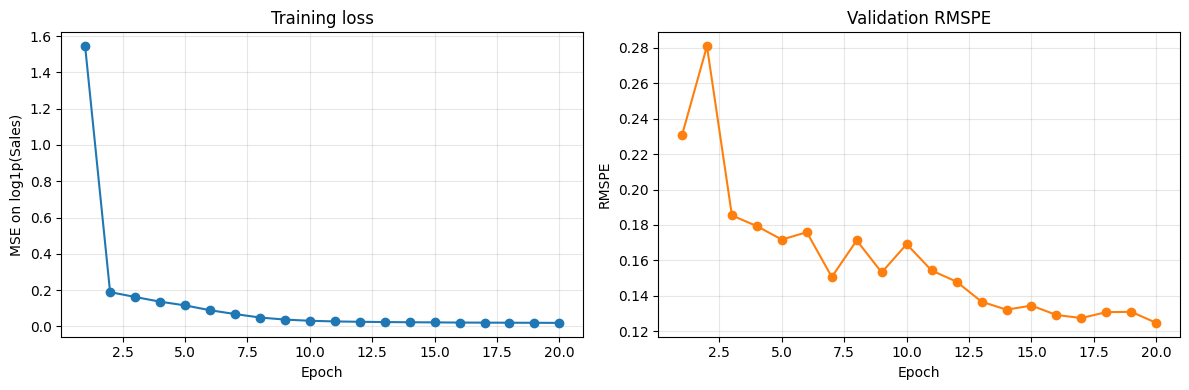

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_mse_log_sales"], marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE on log1p(Sales)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_rmspe"], marker="o", color="tab:orange")
axes[1].set_title("Validation RMSPE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSPE")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Evaluate the Best Model on Validation Data

In [11]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

val_log_predictions = predict_log_sales(model, val_loader)
val_sales_predictions = log_predictions_to_sales(val_log_predictions, val_df["Open"].values)

validation_results = {
    "rmspe": float(rmspe(val_df[target_column].values, val_sales_predictions)),
    "mae": float(mae(val_df[target_column].values, val_sales_predictions)),
}

validation_results

C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_23956\2169472520.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_loca

{'rmspe': 0.12468668506105784, 'mae': 572.6765965874114}

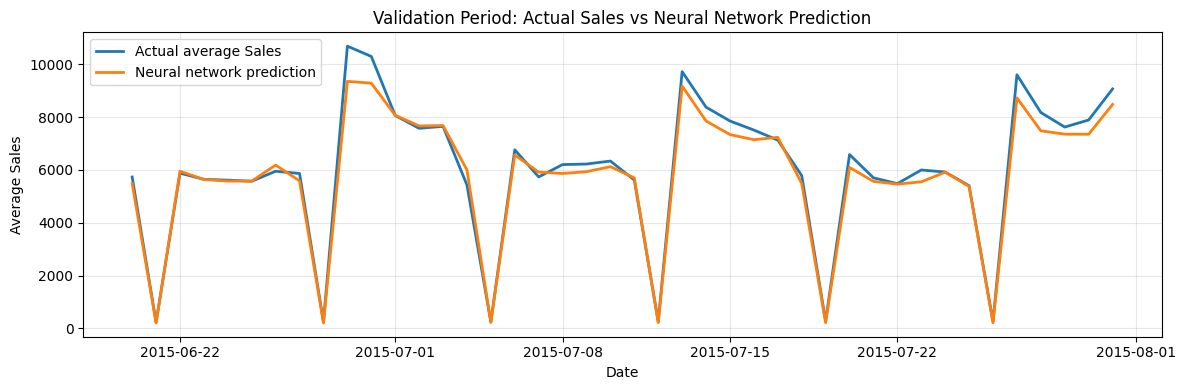

In [12]:
validation_plot_df = val_df[["Date", "Store", "Sales", "Open"]].copy()
validation_plot_df["prediction"] = val_sales_predictions

daily_validation = (
    validation_plot_df.groupby("Date", as_index=False)[["Sales", "prediction"]]
    .mean()
    .sort_values("Date")
)

plt.figure(figsize=(12, 4))
plt.plot(daily_validation["Date"], daily_validation["Sales"], label="Actual average Sales", linewidth=2)
plt.plot(daily_validation["Date"], daily_validation["prediction"], label="Neural network prediction", linewidth=2)
plt.title("Validation Period: Actual Sales vs Neural Network Prediction")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our model is much better than baseline based on the plot only. Later we will compare in a more robust way, but NICE

## 12. Compare With the Part 02 Baseline

(if this part does not return anything, it's because notebook 02 has not run correctly. Try and run notebook 02 and run this cell again)

In [13]:
baseline_summary_path = PREPARED_DIR / "part_02_supervised_task_summary.json"

comparison_rows = [
    {
        "model": "PyTorch neural network",
        "validation_rmspe": validation_results["rmspe"],
        "validation_mae": validation_results["mae"],
    }
]

if baseline_summary_path.exists():
    with open(baseline_summary_path, "r", encoding="utf-8") as f:
        part_02_summary = json.load(f)
    baseline_results = part_02_summary.get("baseline_results", {})
    comparison_rows.insert(
        0,
        {
            "model": "Store + day-of-week baseline",
            "validation_rmspe": baseline_results.get("validation_rmspe"),
            "validation_mae": baseline_results.get("validation_mae"),
        },
    )
else:
    print("Part 02 baseline summary not found. Run 02_supervised_learning_task.ipynb to include the baseline comparison.")

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,model,validation_rmspe,validation_mae
0,Store + day-of-week baseline,0.235572,1078.810968
1,PyTorch neural network,0.130679,570.872358


## 13. Predict the Test Set and Save a Submission File

In [14]:
test_log_predictions = predict_log_sales(model, test_loader)
test_sales_predictions = log_predictions_to_sales(test_log_predictions, test_df["Open"].values)

if "Id" in test_df.columns:
    submission_df = pd.DataFrame({"Id": test_df["Id"].values, "Sales": test_sales_predictions})
else:
    submission_df = test_df[["Store", "Date"]].copy()
    submission_df["Sales"] = test_sales_predictions

submission_path = PREDICTION_DIR / "submission_pytorch_nn.csv"
submission_df.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path.resolve())
display(submission_df.head())

Saved submission to: C:\Users\Vaibhav\Documents\IML\outputs\predictions\submission_pytorch_nn.csv


,Id,Sales
0,40233,4735.856445
1,40234,4800.577637
2,40235,6945.193848
3,40236,3771.213867
4,40237,6915.546875


In [18]:
print(len(submission_df))
print(submission_df.columns)
print("The columns in the test df are", test_df.columns)
print("The len of test df", len(test_df))

41088
Index(['Id', 'Sales'], dtype='object')
The columns in the test df are Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'year', 'month', 'day',
       'weekofyear', 'quarter', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'days_since_start', 'dow_sin', 'dow_cos', 'month_sin',
       'month_cos', 'competition_open_months', 'promo2_active'],
      dtype='object')
The len of test df 41088


In [20]:
plot_df = test_df[["Id", "Store", "Date"]].merge(
    submission_df[["Id", "Sales"]],
    on="Id",
    how="inner"
)

plot_df = plot_df.sort_values(["Store", "Date"])

In [24]:
print("The number of stores", plot_df["Store"].unique)

The number of stores <bound method Series.unique of 0           1
856         1
1712        1
2568        1
3424        1
         ... 
37663    1115
38519    1115
39375    1115
40231    1115
41087    1115
Name: Store, Length: 41088, dtype: int64>


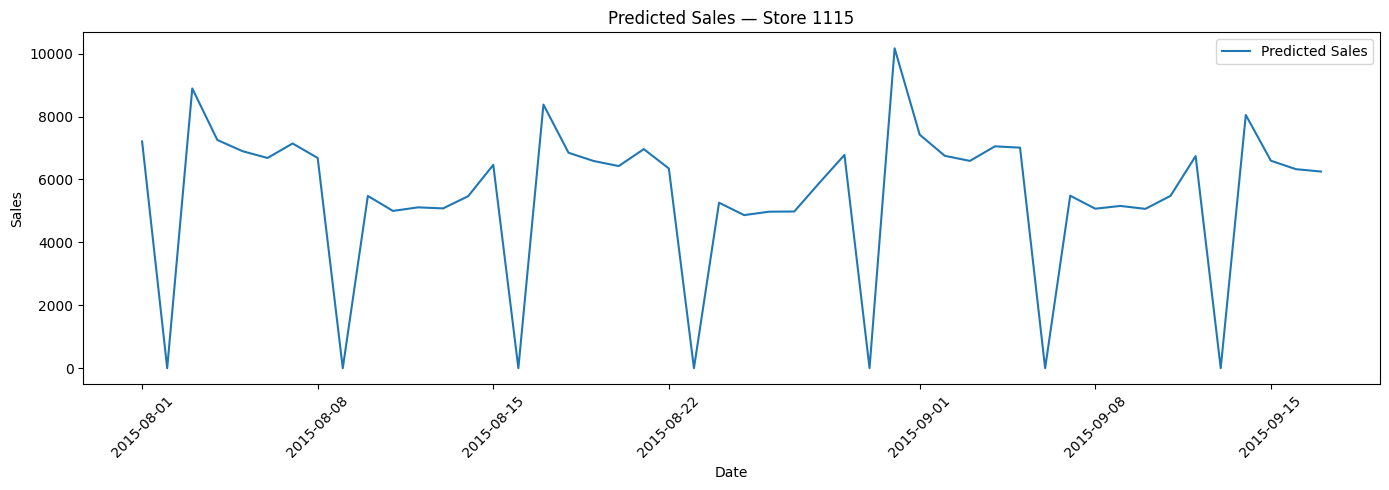

In [25]:
store_id = 1115

store_df = plot_df[plot_df["Store"] == store_id].sort_values("Date")

plt.figure(figsize=(14, 5))
plt.plot(store_df["Date"], store_df["Sales"], label="Predicted Sales")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title(f"Predicted Sales — Store {store_id}")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Save Modeling Artifacts

The model weights are saved separately from the preprocessing metadata. The metadata records feature lists, category mappings, scaling values, hyperparameters, and validation results.

In [15]:
artifact_summary = {
    "model_path": str(best_model_path),
    "submission_path": str(submission_path),
    "target_column": target_column,
    "training_target": training_target,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "category_maps": category_maps,
    "numeric_means": {column: float(value) for column, value in numeric_means.items()},
    "numeric_stds": {column: float(value) for column, value in numeric_stds.items()},
    "embedding_cardinalities": embedding_cardinalities,
    "embedding_dimensions": embedding_dimensions,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "dropout": DROPOUT,
    },
    "validation_results": validation_results,
}

artifact_path = MODEL_DIR / "tabular_sales_nn_metadata.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(artifact_summary, f, indent=2)

history_path = MODEL_DIR / "tabular_sales_nn_history.csv"
history_df.to_csv(history_path, index=False)

validation_predictions_path = PREDICTION_DIR / "validation_predictions_pytorch_nn.csv"
validation_plot_df.to_csv(validation_predictions_path, index=False)

print("Saved model weights:", best_model_path.resolve())
print("Saved metadata:", artifact_path.resolve())
print("Saved training history:", history_path.resolve())
print("Saved validation predictions:", validation_predictions_path.resolve())

Saved model weights: C:\Users\Vaibhav\Documents\IML\outputs\models\tabular_sales_nn.pt
Saved metadata: C:\Users\Vaibhav\Documents\IML\outputs\models\tabular_sales_nn_metadata.json
Saved training history: C:\Users\Vaibhav\Documents\IML\outputs\models\tabular_sales_nn_history.csv
Saved validation predictions: C:\Users\Vaibhav\Documents\IML\outputs\predictions\validation_predictions_pytorch_nn.csv
